In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

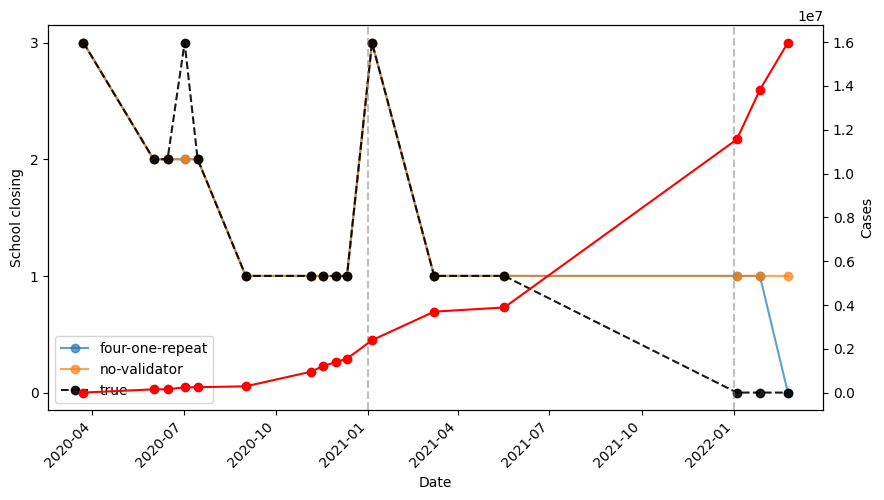

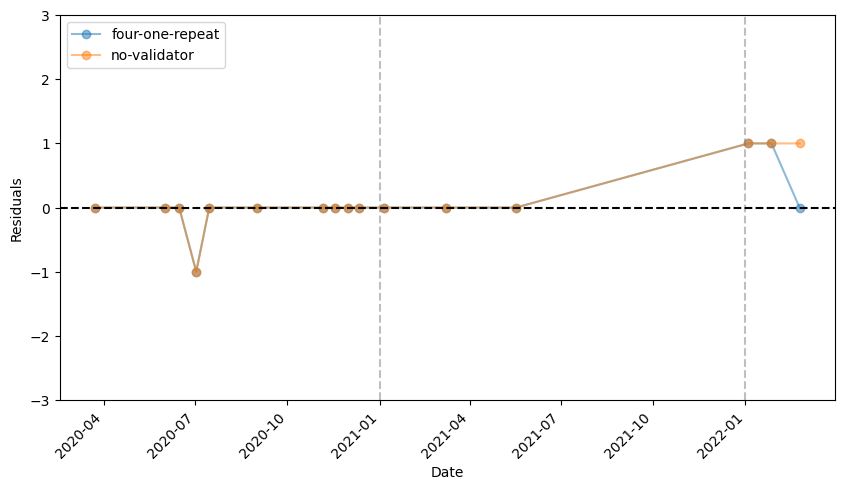

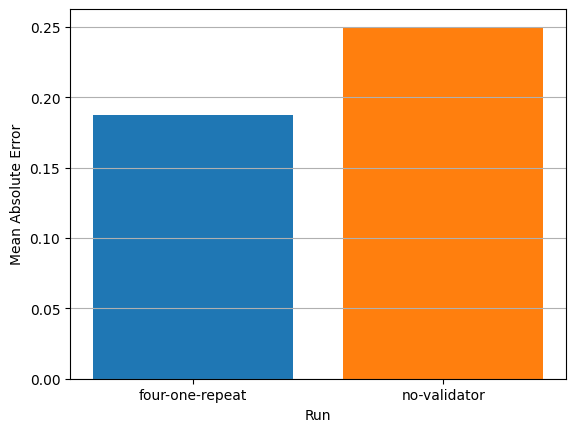

In [16]:
def compare_results(results_dirs: dict[str, str], label_path: str):

    fig, ax = plt.subplots(figsize=(10, 5))

    labels = pd.read_csv(label_path)
    labels["Date"] = pd.to_datetime(labels["Date"])
    labels = labels.sort_values(by="Date")
    labels["Score"] = labels["Score"].astype(int)

    resid_dict = {}

    for label, path in results_dirs.items():
        preds = pd.read_csv(path)
        preds["Date"] = pd.to_datetime(preds["Date"])
        preds = preds.sort_values(by="Date")

        preds["Score"] = preds["Score"].fillna("0")
        preds["Score"] = preds["Score"].astype(str)
        valid_scores = ["0", "1", "2", "3"]
        # any score not in valid scores should be set to 0
        preds["Score"] = preds["Score"].apply(lambda x: x if x in valid_scores else "0")
        preds["Score"] = preds["Score"].astype(int)

        merged = pd.merge(labels, preds, on="Date", suffixes=("", "_Pred"), how="left")
        merged["Score_Pred"] = merged["Score_Pred"].fillna(0)

        resid_dict[label] = merged["Score_Pred"] - merged["Score"]

        ax.plot(preds["Date"], preds["Score"], marker="o", alpha=0.7, label=label)

    ax.plot(labels["Date"], labels["Score"], marker="o", color="black", alpha=0.9, linestyle="--", label="true")

    ax.axvline(pd.to_datetime("2021-01-01"), color="gray", linestyle="--", alpha=0.5)
    ax.axvline(pd.to_datetime("2022-01-01"), color="gray", linestyle="--", alpha=0.5)

    ax.legend()
    ax.set_xlabel("Date")
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticks([0, 1, 2, 3])
    ax.set_ylabel("School closing")

    # Plot cases on secondary axis
    ax2 = ax.twinx()
    ax2.set_ylabel("Cases")
    ax2.plot(labels["Date"], labels["ConfirmedCases"], color="red", marker="o", label="Cases")

    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    for label, residuals in resid_dict.items():
        ax.plot(labels["Date"], residuals, marker="o", alpha=0.5, label=label)

    ax.axvline(pd.to_datetime("2021-01-01"), color="gray", linestyle="--", alpha=0.5)
    ax.axvline(pd.to_datetime("2022-01-01"), color="gray", linestyle="--", alpha=0.5)
    ax.axhline(0, color="black", linestyle="--")

    ax.legend()
    ax.set_xlabel("Date")
    ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticks([-3, -2, -1, 0, 1, 2, 3])
    ax.set_ylabel("Residuals")

    plt.show()

    mae_dict = dict(resid_dict)
    for label in mae_dict:
        mae_dict[label] = mae_dict[label].abs().mean()
    fig, ax = plt.subplots()
    ax.grid(axis="y")
    ax.bar(mae_dict.keys(), mae_dict.values(), color=[f"C{i}" for i in range(len(mae_dict))])
    ax.set_ylabel("Mean Absolute Error")
    ax.set_xlabel("Run")

    plt.show()

compare_results(
    {"four-one-repeat": "logs/four-one-repeat-0/persistence.csv",
     "no-validator": "logs/no-validator/persistence.csv"},
     "data/england-dataset.csv"
)

# compare_results(
#     {f"four-one-repeat-{i}": f"../logs/four-one-repeat-{i}/persistence.csv" for i in range(10)},
#     "england.csv"
# )

# compare_results(
#     {
#         "england": "../logs/england/persistence.csv",
#         "new-hocon": "../logs/new-hocon/persistence.csv",
#         "new-hocon-2": "../logs/new-hocon-2/persistence.csv",
#         "new-hocon-3": "../logs/new-hocon-3/persistence.csv",
#         "validator": "../logs/validator/persistence.csv",
#     },
#     "england.csv"
# )

0.046116549210788865
0.19375


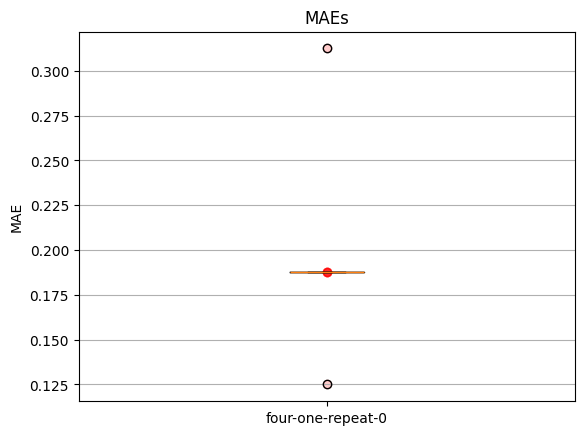

In [7]:
def compare_repeats(all_results_paths: list[list[str]], label_path: str):
    labels = pd.read_csv(label_path)
    labels["Date"] = pd.to_datetime(labels["Date"])


    fig, ax = plt.subplots()
    for i, results_paths in enumerate(all_results_paths):

        errors = []
        for results_path in results_paths:
            preds = pd.read_csv(results_path)
            preds["Date"] = pd.to_datetime(preds["Date"])
            valid_scores = ["0", "1", "2", "3"]
            preds["Score"] = preds["Score"].astype(str).apply(lambda x: x if x in valid_scores else "0")
            preds["Score"] = preds["Score"].astype(int)

            merged = labels.merge(preds, on="Date", how="left", suffixes=("", "_Pred")).copy()
            merged["Score_Pred"] = merged["Score_Pred"].fillna(0)
            error = merged["Score_Pred"] - merged["Score"]
            mae = error.abs().mean()
            errors.append(mae)
        
        stdev = pd.Series(errors).std()
        print(stdev)
        mean = pd.Series(errors).mean()
        print(mean)

        ax.boxplot(errors, positions=[i+1])
        ax.scatter([i+1] * len(errors), errors, color="red", alpha=0.2)

    ax.set_title("MAEs")
    ax.set_ylabel("MAE")
    x_names = [r[0].split("/")[-2] for r in all_results_paths]
    ax.set_xticks(range(1, len(x_names)+1), x_names)
    ax.grid(axis="y")

    plt.show()

# repeats = [
#     [f"../logs/mini-repeat-{i}/persistence.csv" for i in range(10)],
#     [f"../logs/mini-historian-repeat-{i}/persistence.csv" for i in range(5)],
# ]

repeats = [[f"logs/four-one-repeat-{i}/persistence.csv" for i in range(10)]]

compare_repeats(repeats, "data/england-dataset.csv")

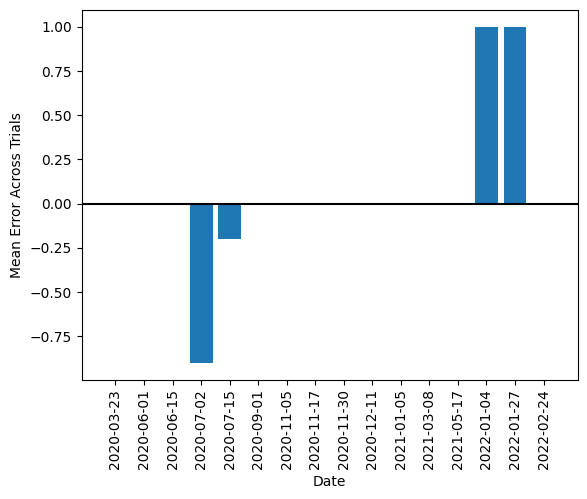

In [8]:
def question_average_correctness(results_paths: list[str], label_path: str):
    labels = pd.read_csv(label_path)
    labels["Date"] = pd.to_datetime(labels["Date"])

    all_errors = []
    for path in results_paths:
        preds = pd.read_csv(path)
        preds["Date"] = pd.to_datetime(preds["Date"])
        preds["Score"] = preds["Score"].astype(str).apply(lambda x: x if x in ["0", "1", "2", "3"] else "0")
        preds["Score"] = preds["Score"].astype(int)

        merged = labels.merge(preds, on="Date", how="left", suffixes=("", "_Pred")).copy()
        merged["Score_Pred"] = merged["Score_Pred"].fillna(0)
        error = merged["Score_Pred"] - merged["Score"]
        all_errors.append(error.to_list())

    all_errors = np.array(all_errors)
    mean_question_errors = np.mean(all_errors, axis=0)

    fig, ax = plt.subplots()
    ax.bar(range(len(mean_question_errors)), mean_question_errors)
    ax.set_xlabel("Date")
    ax.set_ylabel("Mean Error Across Trials")
    ax.axhline(0, color="black")
    ax.set_xticks(range(len(mean_question_errors)), labels["Date"].apply(lambda x: x.date()), rotation=90)
    plt.show()

question_average_correctness(repeats[0], "data/england-dataset.csv")

In [9]:
def get_wrong_with_notes(results_path: str, label_path: str):
    preds = pd.read_csv(results_path)
    labels = pd.read_csv(label_path)

    labels["Date"] = pd.to_datetime(labels["Date"])
    preds["Date"] = pd.to_datetime(preds["Date"])

    labels = labels.merge(preds[["Date", "Score", "Notes"]], on="Date", how="left", suffixes=("", "_Pred"))

    wrong = labels[labels["Score"] != labels["Score_Pred"]]
    for _, row in wrong.iterrows():
        print(row["Date"].date(), row["Score_Pred"], row["Score"])
        print("\t", row["Notes_Pred"])
        print("\t", row["Notes"])

get_wrong_with_notes("logs/four-one-repeat-8/persistence.csv", "data/england-dataset.csv")

2020-07-02 2.0 3.0
	 On 2020-07-02, England's national policy remained a partial reopening of schools (C1=2), with only some levels/categories closed, except for Leicester and nearby areas which reverted to full closure (C1=3 targeted). This is supported by government and news sources and matches OxCGRT guidelines, which require recording the most stringent general policy as national and more stringent local measures as targeted (see GOV.UK 29 June, Leicester Council, BBC 30 June, and OxCGRT guidance).
	 2 July     Schools closed at all levels during regional lockdown in Leicester after a spike in cases.    Schools closed for all levels from Thursday 2 July and told not to reopen until next term (September). Coded this as a 3 until the end of the school term which in Leicester is 14th July. 2G coding will therefore resume on this date to best represent the national situation.    National Government source 29th June: https://web.archive.org/web/20200713102328/https://www.gov.uk/governme

In [10]:
def check_validator_necessary(log_path: str):
    n_fails = 0
    with open(log_path, "r", encoding="utf-8") as f:
        content = f.read()
        n_fails += content.count("Needs Revision")
    print(n_fails)
    return n_fails

log_paths = [f"logs/four-one-repeat-{i}/news_analyst.validator_coordinator" for i in range(10)]
n_fails = sum(check_validator_necessary(log_path) for log_path in log_paths)
print(n_fails)

32
32
32
32
32
32
32
32
30
32
318


In [11]:
import re
import json
def analyze_cost(log_path: str):
    with open(log_path, "r", encoding="utf-8") as f:
        text = f.read()
        """
        Finds all blocks of text that start with [AGENT]:\n{ and
        captures the text between the first opening and closing curly braces.
        Returns a list of strings.
        """
        pattern = r'\[AGENT\]:\n\{(.*?)\}'
        costs = re.findall(pattern, text, re.DOTALL)
        costs = [json.loads("{" + cost + "}") for cost in costs]
        return costs

costs = analyze_cost("logs/four-one-repeat-0/news_analyst")
keys = costs[0].keys()
total = {key: 0 for key in keys}
for cost in costs:
    for key, value in cost.items():
        if key != "caveats":
            total[key] += value
print(json.dumps(total, indent=4))

labels = pd.read_csv("data/england-dataset.csv")
article_col = labels["Source"].tolist()
n = 0
for articles in article_col:
    n += len(articles.split(","))
print(n, "articles")

{
    "caveats": 0,
    "completion_tokens": 38529.0,
    "prompt_tokens": 912617.0,
    "successful_requests": 164.0,
    "time_taken_in_seconds": 696.4642796516418,
    "total_cost": 1.6634499999999999,
    "total_tokens": 951146.0
}
26 articles
